<a href="https://www.kaggle.com/code/khoatran311/r-analysis-notebook?scriptVersionId=305215835" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
library(tidyverse)
library(GGally) # use ggpairs(columns=c(...)) for pair plots of predictors
library(patchwork)
library(data.table)
library(emmeans)
library(MASS)
library(car)
library(lme4) # use lmer, gamm
library(mgcv) # use gam, gam.check(), plot(), plot_predictions()
library(bayesplot) # use bayes_R2(brm_model), mcmc_acf(as.array(brm_model), pars = vector_slope_intercept_names)
library(brms) # use brm, prior_summary(), posterior_summary(), pp_check(), plot(), plot_predictions(), conditional_effects(), print(loo(brm_model))
library(scales)
library(broom)

theme_custom <- theme_classic() +
                theme(## Axis labels
                      axis.text.y  = element_text(size=16, face="bold", color="#333333"),
                      axis.text.x  = element_text(size=20, color="#333333"),
                      ## Title, subtitle, caption, legend
                      plot.title   = element_text(size=26, face="bold", color="#333333"),
                      plot.subtitle = element_text(size=23, color="#333333"),
                      plot.caption = element_text(size=12, colour="#333333", hjust=0),
                      legend.position = "top",
                      legend.text = element_text(size=20),
                      legend.title = element_blank(),
                      legend.key.spacing.x = unit(1.0, "cm"),
                      axis.title.x = element_text(size=20, margin=margin(t=10,b=10)),
                      axis.title.y = element_text(size=20, margin=margin(l=10,r=10)),
                      strip.text = element_text(size=20),
                      ## axis lines
                      panel.grid.major.y = element_line(color="#6F8793"),
                      axis.ticks.y = element_blank(),
                      axis.ticks.x = element_blank(),
                     )
                     
figsize <- function(width=22, height=8){
    options(repr.plot.width=width, repr.plot.height=height)
}
figsize()

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.2     


── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


Registered S3 method overwritten by 'GGally':
  method from   
  +.gg   ggplot2




Attaching package: ‘data.table’




The following objects are masked from ‘package:lubridate’:

    hour, isoweek, mday, minute, month, quarter, second, wday, week,
    yday, year




...

The following object is masked from ‘package:lme4’:

    ngrps




The following object is masked from ‘package:stats’:

    ar





Attaching package: ‘scales’




The following object is masked from ‘package:purrr’:

    discard




The following object is masked from ‘package:readr’:

    col_factor




# Data Loading

In [2]:
train <- read_csv("/kaggle/input/competitions/the-perfect-fit/dataset.csv")
test  <- read_csv("/kaggle/input/competitions/the-perfect-fit/test.csv")
sample_submission <- read_csv("/kaggle/input/competitions/the-perfect-fit/sample_submission.csv")

Rows: 1500 Columns: 14


── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (2): Country, City
dbl (12): id, x1, x2, x4, x5, x6, x7, x8, x9, x10, x11, target



ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 1500 Columns: 13


── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (2): Country, City
dbl (11): id, x1, x2, x4, x5, x6, x7, x8, x9, x10, x11



ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 1500 Columns: 2


── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl (2): id, target



ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


## Quick Inspections

In [3]:
head(train, 4)

id,x1,x2,Country,City,x4,x5,x6,x7,x8,x9,x10,x11,target
<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0,-0.1750505,0.2092847,Spain,Zaragoza,-0.3427309,11.46936,-17.528967,-4.090882,-0.2992959,4.957600,5.7134631,5.180641,-31.57924
1,0.4404146,-0.2955612,Spain,Zaragoza,-0.3690915,11.96563,-9.459683,15.313863,-0.2796488,3.209983,3.8730255,3.838939,-50.79896
2,0.4140079,0.3805125,Spain,Zaragoza,-0.4575798,10.58534,8.834357,15.682925,-0.4209734,3.140112,0.5257111,1.805406,-42.30120
3,-0.2134906,-0.2173672,Spain,Albacete,-0.4211545,11.30658,17.789389,2.745475,-0.2798813,3.358094,5.1279074,2.663848,-17.24889


In [4]:
head(test, 4)

id,x1,x2,Country,City,x4,x5,x6,x7,x8,x9,x10,x11
<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1500,-0.4059104,0.2722858,Spain,Zaragoza,-0.06613227,999.000000,0.1585852,-17.999301,-0.05411403,6.952984,3.101912,5.6966543
1501,-0.3722625,0.4626097,Spain,Albacete,0.20713733,10.860631,16.9955387,5.928884,-0.38119899,6.695397,1.019275,4.9000856
1502,-0.3624807,-0.4990133,Spain,Albacete,0.21251178,7.280777,-5.8585204,17.019922,-0.02092908,5.457205,3.146917,0.6464223
1503,0.0739611,0.3083892,Spain,Albacete,0.35916498,8.911219,7.7359620,-16.252843,0.46826726,5.005376,1.060827,5.5588397


In [5]:
## No NA counts in train/test data
train %>% is.na() %>% apply(2,sum)
test %>% is.na() %>% apply(2,sum)

id      x1      x2 Country    City      x4      x5      x6      x7      x8 
      0       0       0       0       0       0       0       0       0       0 
     x9     x10     x11  target 
      0       0       0       0

id      x1      x2 Country    City      x4      x5      x6      x7      x8 
      0       0       0       0       0       0       0       0       0       0 
     x9     x10     x11 
      0       0       0

In [6]:
## No duplicates in train/test data
train %>% dplyr::select(!id) %>% duplicated() %>% sum()
test  %>% dplyr::select(!id) %>% duplicated() %>% sum()

[1] 0

[1] 0

In [7]:
train %>% count(Country) %>% rename("Country_trainData"="Country")
test %>%  count(Country) %>% rename("Country_testData"="Country")

Country_trainData,n
<chr>,<int>
Spain,1500


Country_testData,n
<chr>,<int>
Spain,1500


In [8]:
train %>% count(City) %>% rename("City_trainData"="City")
test %>%  count(City) %>% rename("City_testData"="City")

City_trainData,n
<chr>,<int>
Albacete,731
Zaragoza,769


City_testData,n
<chr>,<int>
Albacete,778
Zaragoza,722


In [9]:
train <- 
    train %>%
    mutate(City = if_else(City=="Albacete", 0, 1)) %>%
    dplyr::select(!c("id", "Country"))

test <- 
    test %>%
    mutate(City = if_else(City=="Albacete", 0, 1)) %>%
    dplyr::select(!c("id", "Country"))

write.csv(train, file="train_new.csv", row.names=FALSE)
write.csv(test, file="test_new.csv", row.names=FALSE)

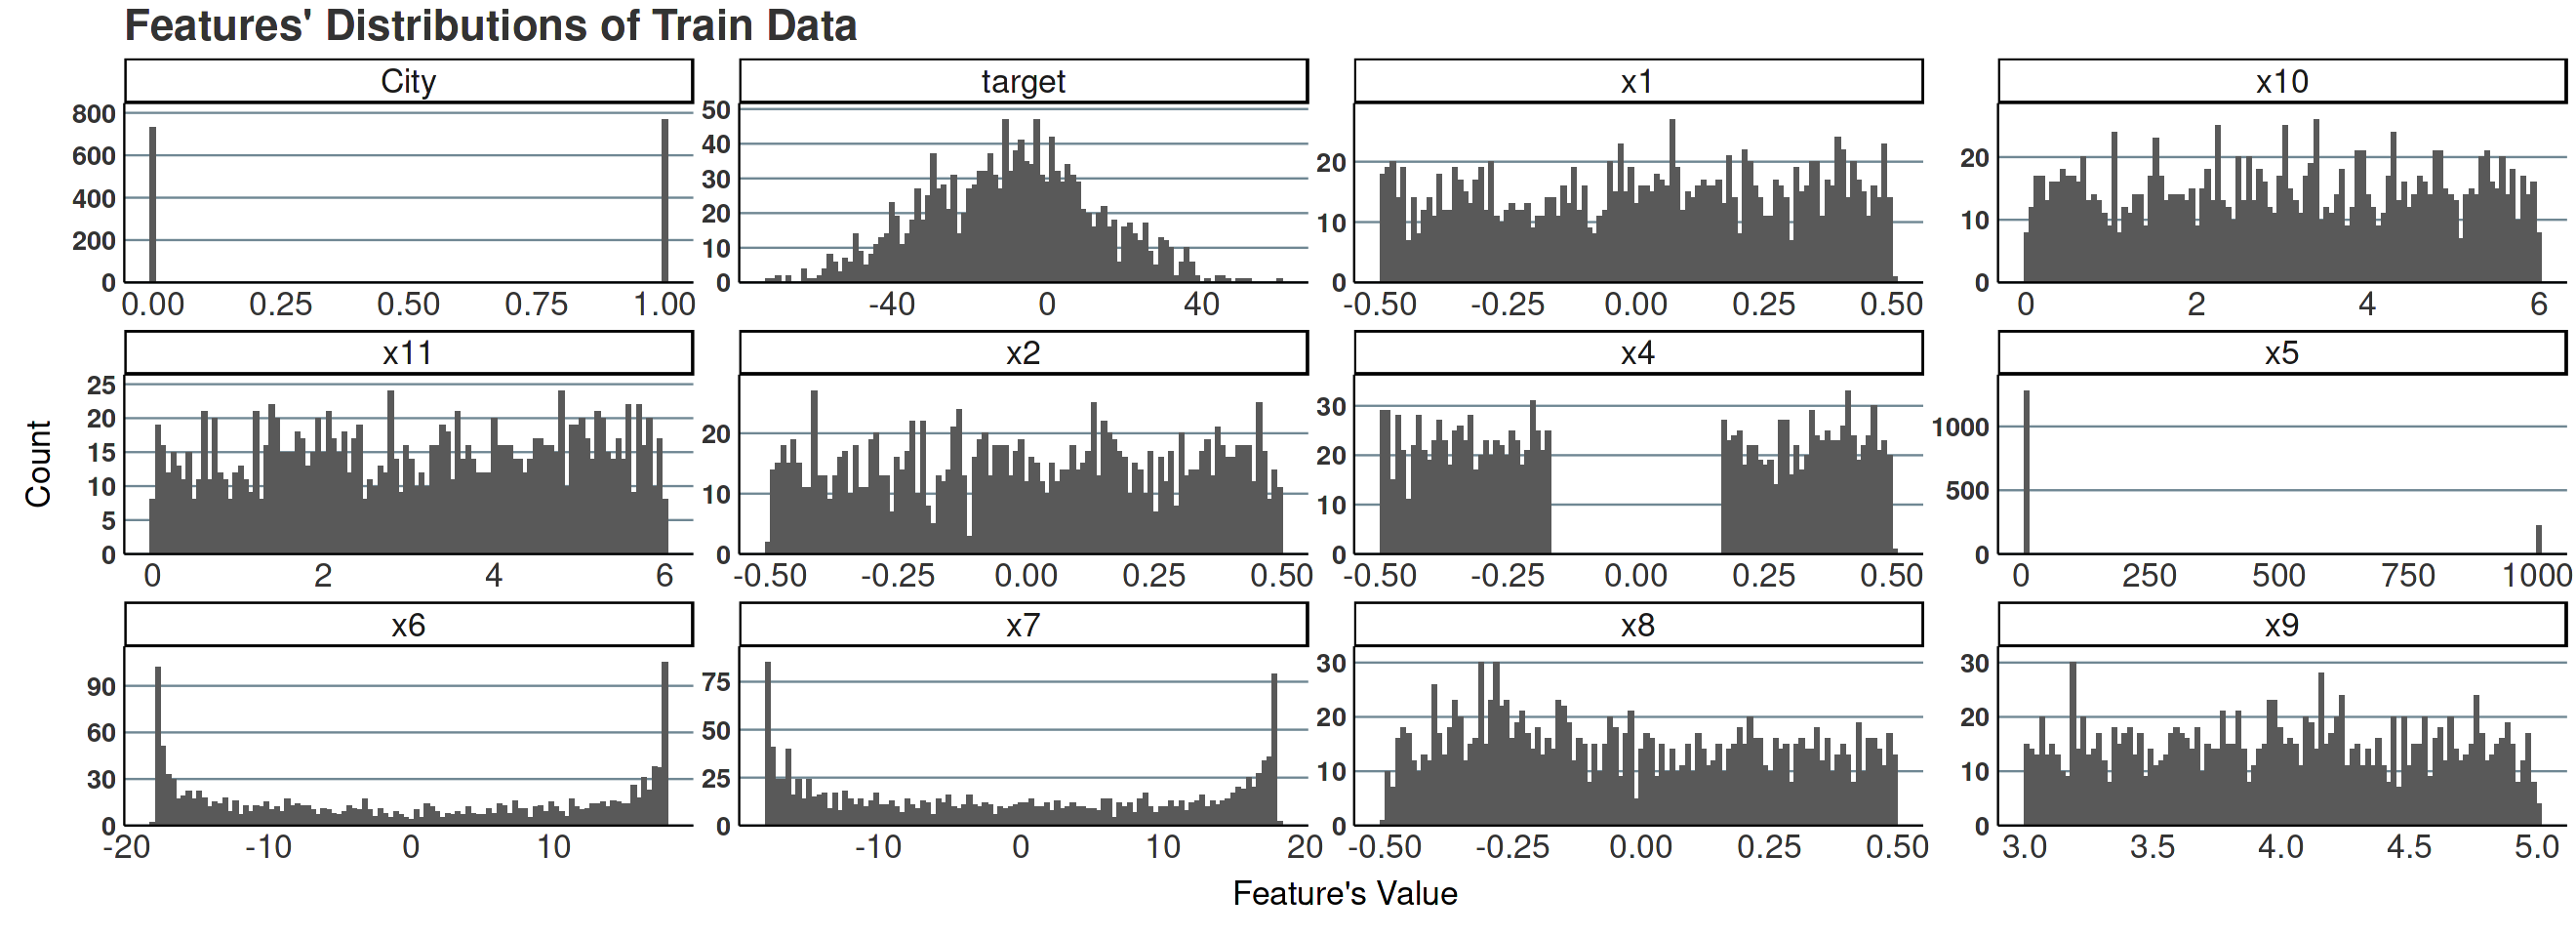

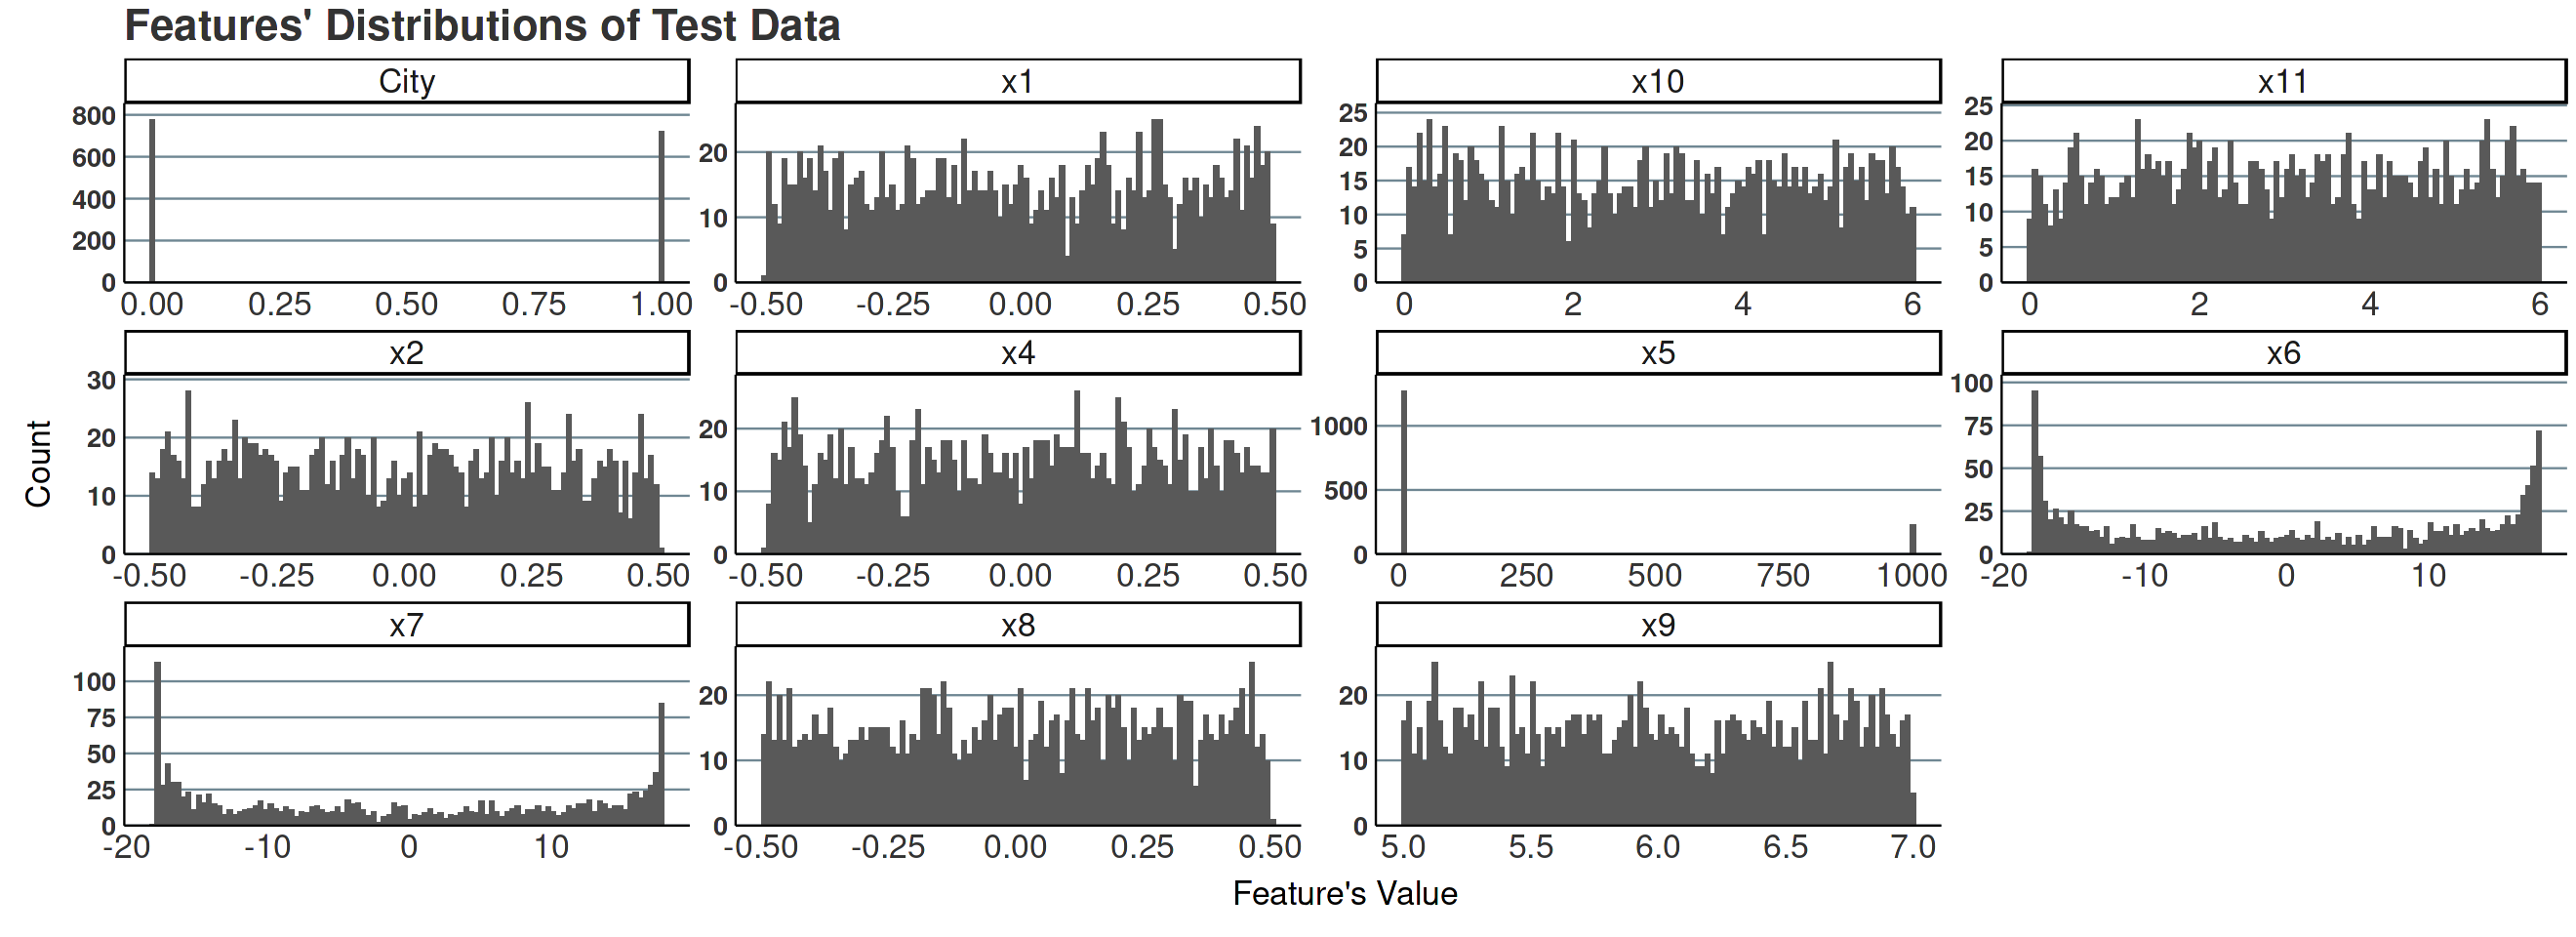

In [10]:
train_distributions <- 
    train %>%
    pivot_longer(
        cols=1:12, names_to="feature"
    ) %>%
    ggplot(aes(x=value)) +
    geom_histogram(bins=100) +
    facet_wrap(~feature, scales="free") +
    scale_y_continuous(expand=expansion(c(0,.1))) +
    labs(
        title="Features' Distributions of Train Data",
        x="Feature's Value", y="Count"
    ) +
    theme_custom


test_distributions <- 
    test %>%
    pivot_longer(
        cols=1:11, names_to="feature"
    ) %>%
    ggplot(aes(x=value)) +
    geom_histogram(bins=100) +
    facet_wrap(~feature, scales="free") +
    scale_y_continuous(expand=expansion(c(0,.1))) +
    labs(
        title="Features' Distributions of Test Data",
        x="Feature's Value", y="Count"
    ) +
    theme_custom

train_distributions
test_distributions

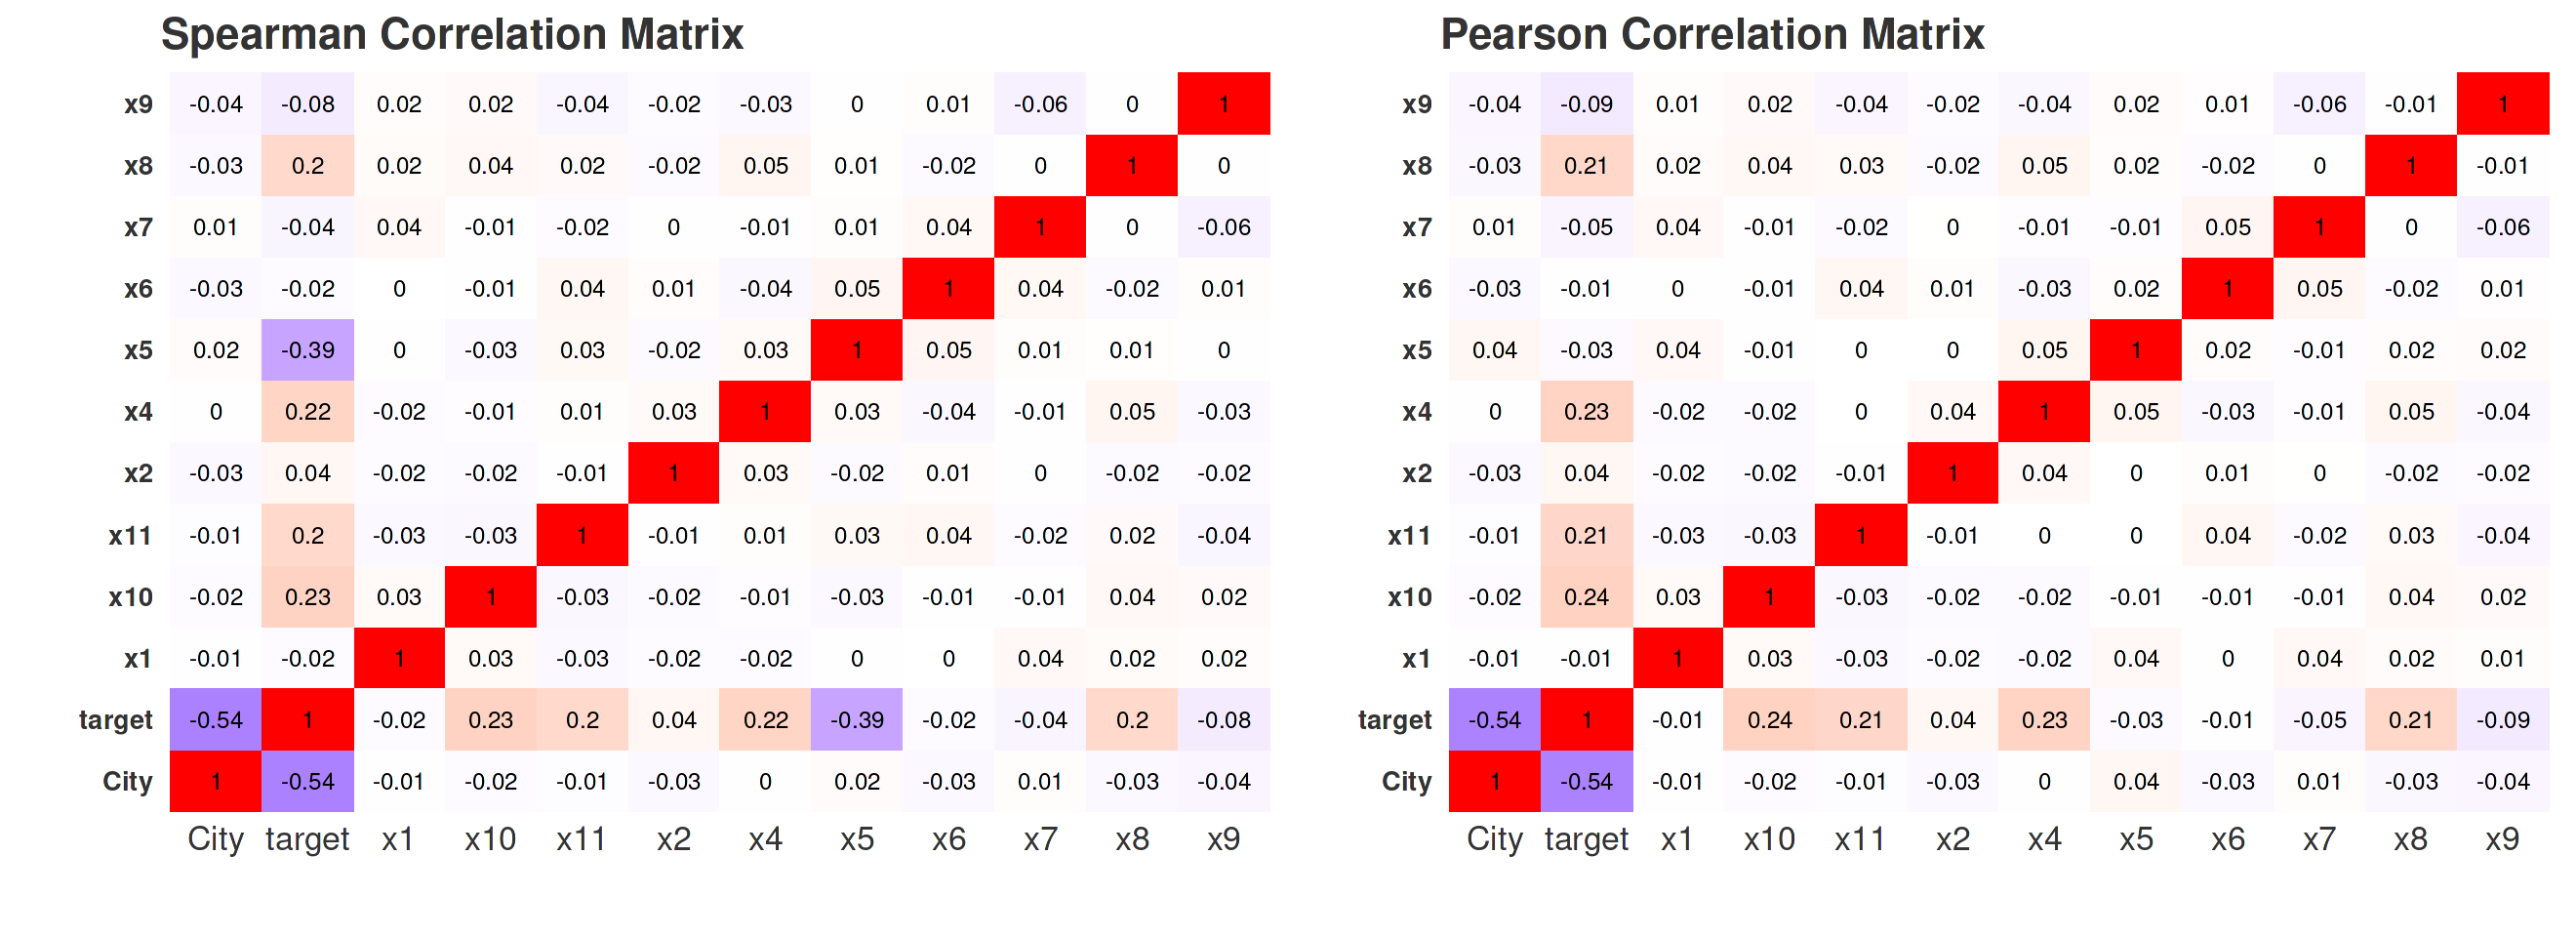

In [11]:
spearman_corr <- 
    train %>% 
    cor(method="spearman") %>%
    data.frame() %>%
    rownames_to_column() %>%
    pivot_longer(
        cols=-rowname, names_to="feature", values_to="corr"
    ) %>%
    ggplot(aes(x=rowname, y=feature, fill=corr)) +
    geom_tile() + 
    geom_text(aes(label=round(corr,2)), size=5) +
    scale_fill_gradient2(low="blue", mid="white", high="red") +
    theme_custom +
    labs(
        title="Spearman Correlation Matrix", x="", y=""
    ) +
    theme(
        panel.grid.major.y = element_blank(),
        axis.line.x = element_blank(),
        axis.line.y = element_blank(),
        legend.position="none"
    )

pearson_corr <- 
    train %>% 
    cor(method="pearson") %>%
    data.frame() %>%
    rownames_to_column() %>%
    pivot_longer(
        cols=-rowname, names_to="feature", values_to="corr"
    ) %>%
    ggplot(aes(x=rowname, y=feature, fill=corr)) +
    geom_tile() + 
    geom_text(aes(label=round(corr,2)), size=5) +
    scale_fill_gradient2(low="blue", mid="white", high="red") +
    theme_custom +
    labs(
        title="Pearson Correlation Matrix", x="", y=""
    ) +
    theme(
        panel.grid.major.y = element_blank(),
        axis.line.x = element_blank(),
        axis.line.y = element_blank(),
        legend.position="none"
    )

spearman_corr + pearson_corr

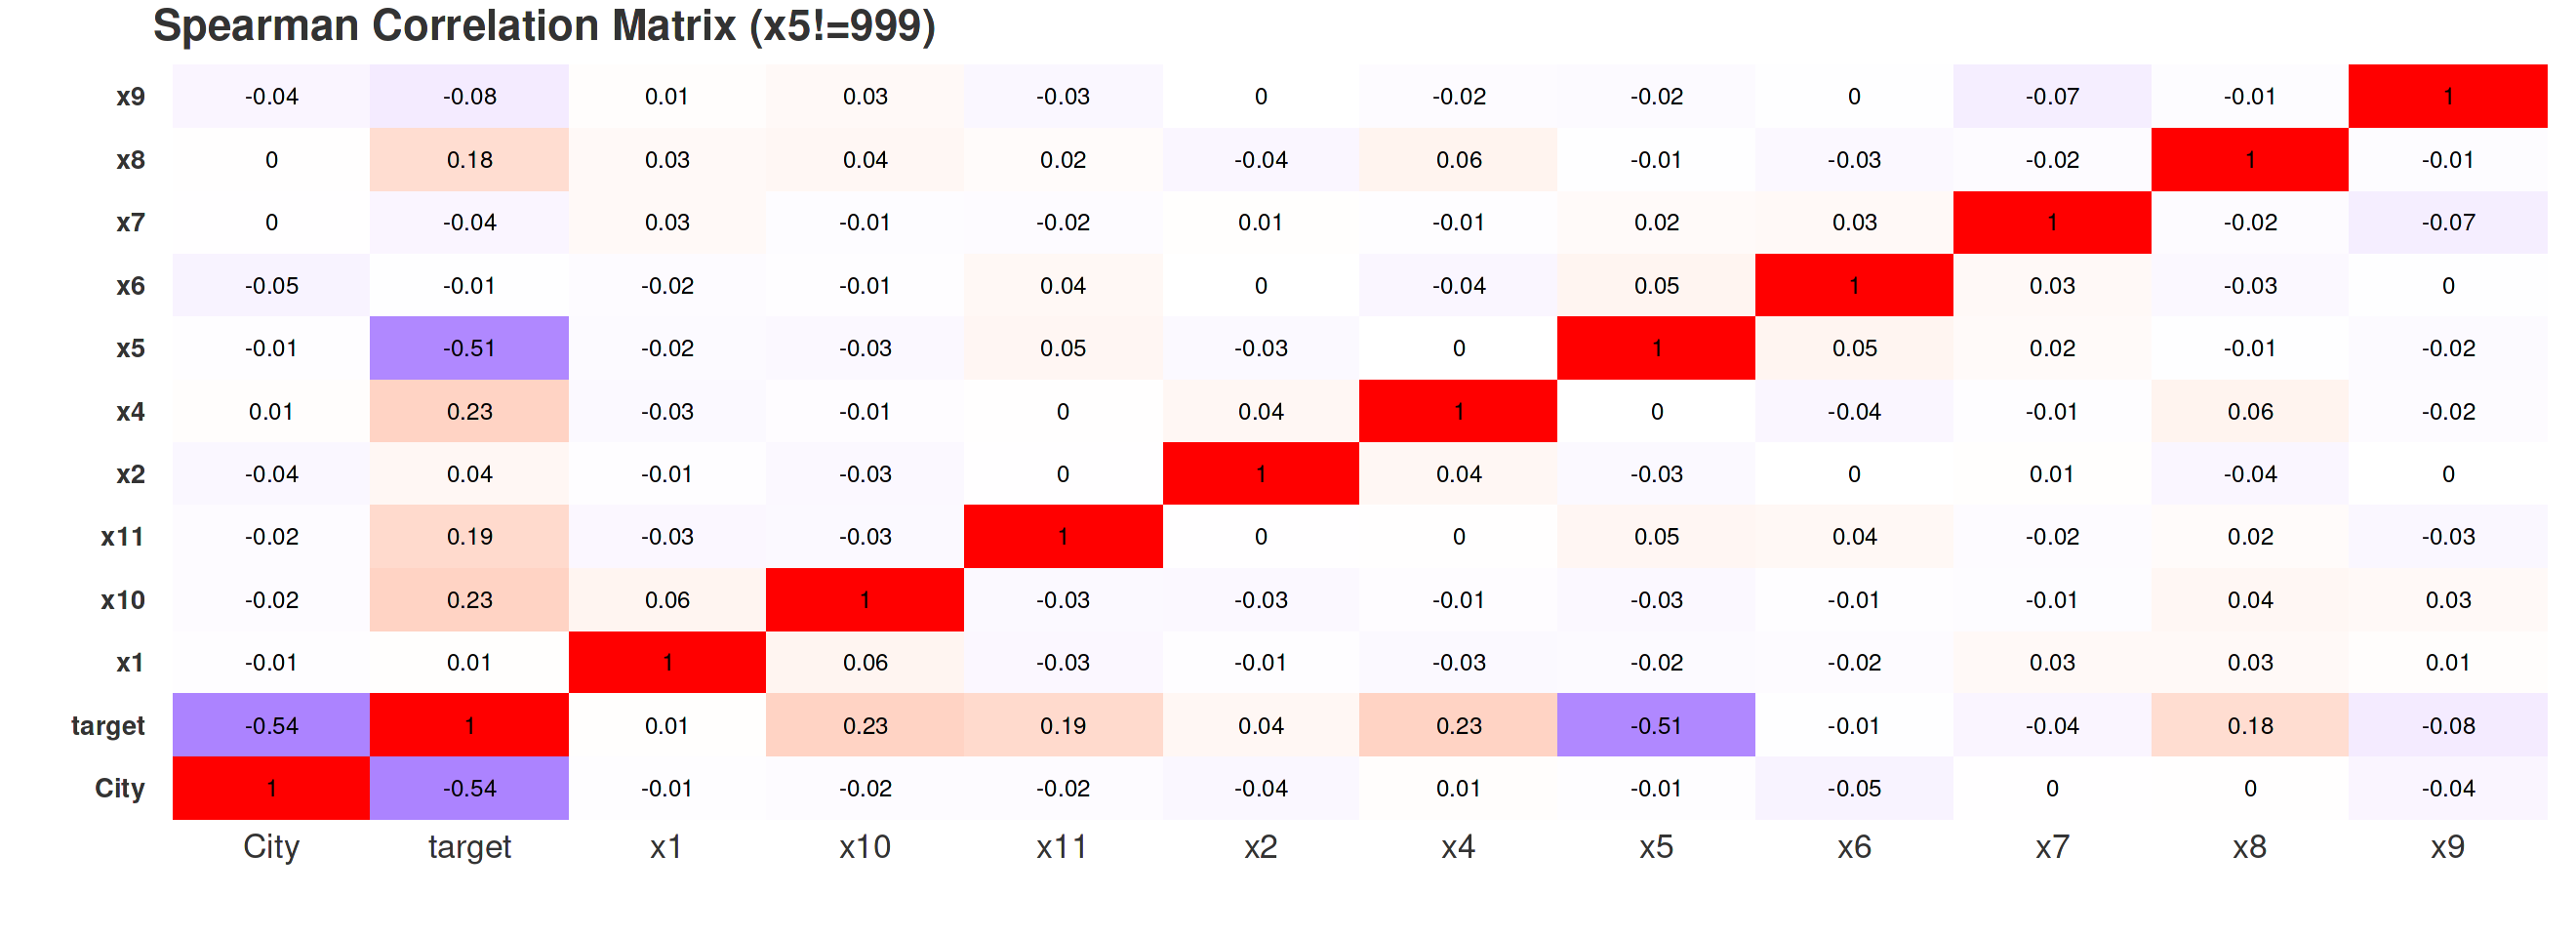

In [12]:
train %>% 
filter(x5!=999) %>%
cor(method="spearman") %>%
    data.frame() %>%
    rownames_to_column() %>%
    pivot_longer(
        cols=-rowname, names_to="feature", values_to="corr"
    ) %>%
    ggplot(aes(x=rowname, y=feature, fill=corr)) +
    geom_tile() + 
    geom_text(aes(label=round(corr,2)), size=5) +
    scale_fill_gradient2(low="blue", mid="white", high="red") +
    theme_custom +
    labs(
        title="Spearman Correlation Matrix (x5!=999)", x="", y=""
    ) +
    theme(
        panel.grid.major.y = element_blank(),
        axis.line.x = element_blank(),
        axis.line.y = element_blank(),
        legend.position="none"
    )

`geom_smooth()` using formula = 'y ~ s(x, bs = "cs")'


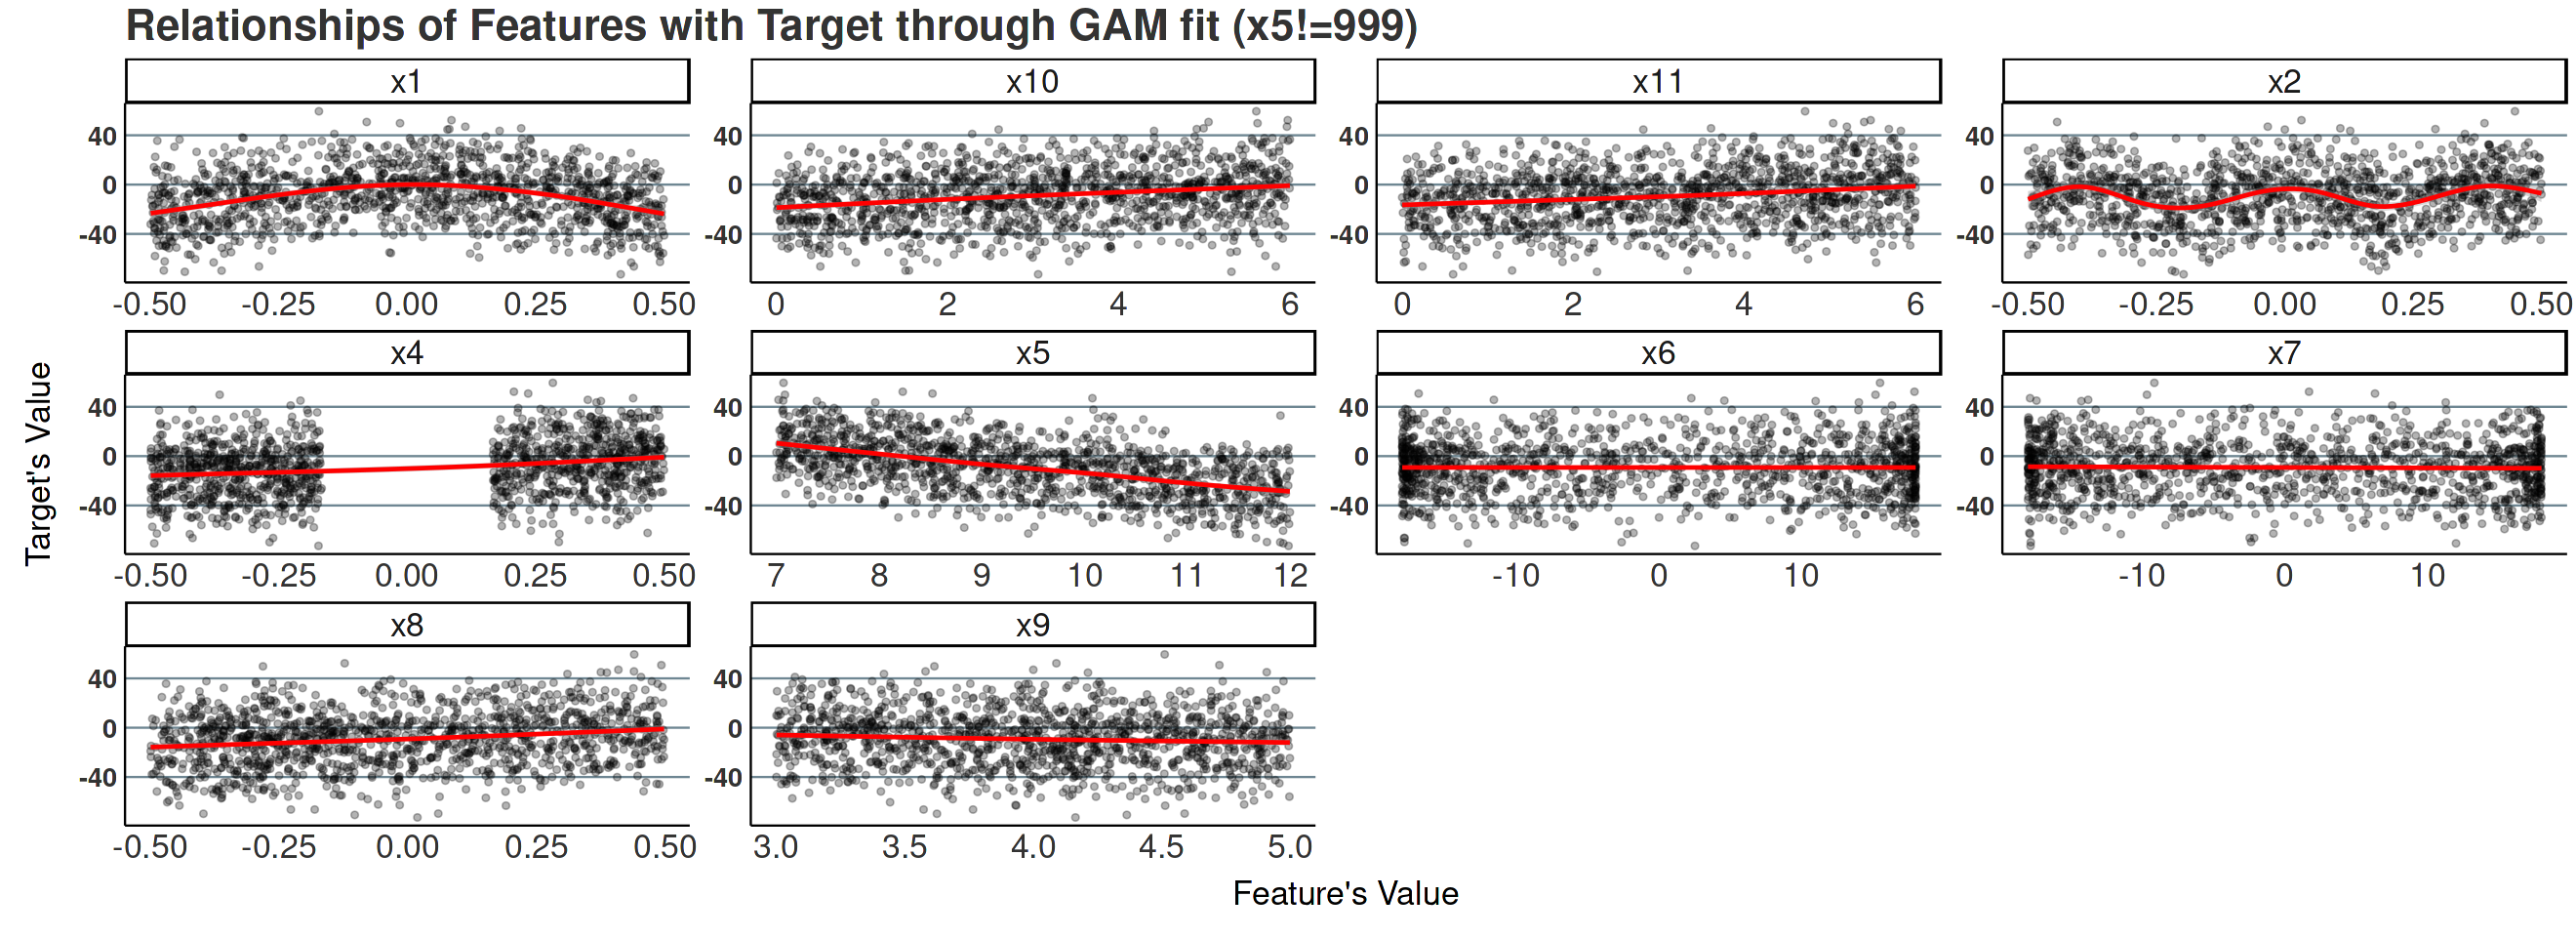

In [13]:
train %>%
    filter(x5!=999) %>%
    dplyr::select(!City) %>%
    pivot_longer(
        cols=-target, names_to="feature"
    ) %>%
    ggplot(aes(x=value, y=target)) +
    geom_point(alpha=.3) + 
    geom_smooth(method="gam", color="red") +
    facet_wrap(~feature, scales="free") +
    labs(
        title="Relationships of Features with Target through GAM fit (x5!=999)",
        x="Feature's Value", y="Target's Value"
    ) +
    theme_custom

In [14]:
train_new <- train %>% filter(x5!=999)

gam_no_x5_999 <- gam(
    target ~
    s(x1) + s(x2) + s(x4) + x5 + 
    s(x6) + s(x7) + s(x8) + s(x9) +
    s(x10) + s(x11) + City,
    data=train_new, method="REML"
) %>% summary()


full_gam <- gam(
    target ~
    s(x1) + s(x2) + s(x4) + s(x5) + 
    s(x6) + s(x7) + s(x8) + s(x9) +
    s(x10) + s(x11) + City,
    data=train, method="REML"
) %>% summary()

In [15]:
gam_no_x5_999


Family: gaussian 
Link function: identity 

Formula:
target ~ s(x1) + s(x2) + s(x4) + x5 + s(x6) + s(x7) + s(x8) + 
    s(x9) + s(x10) + s(x11) + City

Parametric coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept)  79.47146    0.59640   133.3   <2e-16 ***
x5           -8.10129    0.06188  -130.9   <2e-16 ***
City        -24.73863    0.18071  -136.9   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Approximate significance of smooth terms:
         edf Ref.df        F p-value    
s(x1)  7.811  8.632  811.648  <2e-16 ***
s(x2)  8.974  9.000  637.416  <2e-16 ***
s(x4)  1.000  1.001 2948.910  <2e-16 ***
s(x6)  1.000  1.000    0.788   0.375    
s(x7)  1.000  1.000    0.091   0.763    
s(x8)  4.999  6.098  330.060  <2e-16 ***
s(x9)  1.001  1.002  622.972  <2e-16 ***
s(x10) 1.001  1.001 3710.853  <2e-16 ***
s(x11) 1.000  1.001 3354.047  <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

R-sq.(adj) =  0.97

In [16]:
full_gam


Family: gaussian 
Link function: identity 

Formula:
target ~ s(x1) + s(x2) + s(x4) + s(x5) + s(x6) + s(x7) + s(x8) + 
    s(x9) + s(x10) + s(x11) + City

Parametric coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)   3.2734     0.2009   16.29   <2e-16 ***
City        -24.7244     0.2818  -87.73   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Approximate significance of smooth terms:
         edf Ref.df        F p-value    
s(x1)  7.122  8.165  360.339  <2e-16 ***
s(x2)  8.938  8.999  267.131  <2e-16 ***
s(x4)  1.001  1.003 1139.776  <2e-16 ***
s(x5)  2.783  3.224 1878.304  <2e-16 ***
s(x6)  1.001  1.001    0.024   0.878    
s(x7)  1.000  1.001    0.635   0.426    
s(x8)  1.001  1.002  857.363  <2e-16 ***
s(x9)  1.004  1.008  281.510  <2e-16 ***
s(x10) 1.001  1.002 1590.360  <2e-16 ***
s(x11) 1.001  1.002 1372.340  <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

R-sq.(adj) =   0.94   Deviance 

In [17]:
cv_gam <- function(formula, data, k=5){
    ## Defines metric
    mae <- function(y, yhat){mean(abs(y - yhat))}
    ## Define k folds
    set.seed(3126)
    k_folds  <- sample(rep(1:k, length.out = nrow(data)))
    scores <- numeric(k)

    ## Model evaluation
    for (i in 1:k){
        train_fold <- data[k_folds!=i, ]
        val_fold   <- data[k_folds==i, ]
        
        model <- gam(formula, data=train_fold, method="REML")
      
        preds <- predict(model, newdata=val_fold)
        scores[i] <- mae(val_fold$target, preds)
    }
    cat("MAE: ", round(mean(scores),3), "±", round(sd(scores),3), "\n")
    scores
}

In [18]:
train_altered <- 
    train %>%
    mutate(
        x5_outlier = if_else(x5==999, 1, 0),
        x5 = if_else(x5<999, x5, 15)
    )

In [19]:
final_gam <- gam(
    target ~
    s(x1) + s(x2) + x4 + x5 + x5_outlier +
    x6 + x7 + x8 + x9 +
    x10 + x11 + City,
    data=train_altered,
    method="REML"
)

final_gam %>% summary()

cv_gam(
    target ~
    s(x1) + s(x2) + x4 + x5 + x5_outlier +
    x6 + x7 + x8 + x9 +
    x10 + x11 + City,
    train_altered
)


Family: gaussian 
Link function: identity 

Formula:
target ~ s(x1) + s(x2) + x4 + x5 + x5_outlier + x6 + x7 + x8 + 
    x9 + x10 + x11 + City

Parametric coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)  77.662188   1.470841  52.801   <2e-16 ***
x4           13.660169   0.403859  33.824   <2e-16 ***
x5           -8.116416   0.104306 -77.813   <2e-16 ***
x5_outlier   44.536885   0.705170  63.158   <2e-16 ***
x6            0.001722   0.010853   0.159    0.874    
x7           -0.009065   0.011255  -0.805    0.421    
x8           14.401290   0.491329  29.311   <2e-16 ***
x9           -4.178274   0.247875 -16.856   <2e-16 ***
x10           3.229202   0.080858  39.937   <2e-16 ***
x11           3.005732   0.081016  37.100   <2e-16 ***
City        -24.724483   0.281750 -87.753   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Approximate significance of smooth terms:
        edf Ref.df     F p-value    
s(x1) 7.122  8.165 360.

MAE:  3.655 ± 0.186 


[1] 3.619961 3.617482 3.916624 3.717442 3.404043